# Project 2: Data Classification Using AI

## Internship Project – DecodeLabs

### Objective
Build a classification model using the Iris dataset with K-Nearest Neighbors (KNN), evaluate performance, and compare different machine learning algorithms.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Dataset Explanation

The Iris dataset is one of the most popular datasets in machine learning and supervised learning. It contains 150 flower samples divided into three classes:

* Setosa
* Versicolor
* Virginica

Each flower contains four numerical features:

* Sepal length
* Sepal width
* Petal length
* Petal width

The goal of this project is to train a machine learning model that can correctly classify flowers into their corresponding categories based on these measurements.


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)

df["target"] = y

df["flower_name"] = df["target"].apply(
    lambda x: target_names[x]
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print(df.info())

print("\nClass Distribution:\n")
print(df["flower_name"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   flower_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Class Distribution:

flower_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Data Visualization Explanation

Data visualization helps us better understand the dataset before training the model. By plotting the petal length and petal width of different flower classes, we can visually observe how the classes are separated.

Visualization is important because it helps identify patterns, similarities, and differences between the flower categories. It also gives an early indication that classification is possible using machine learning algorithms.


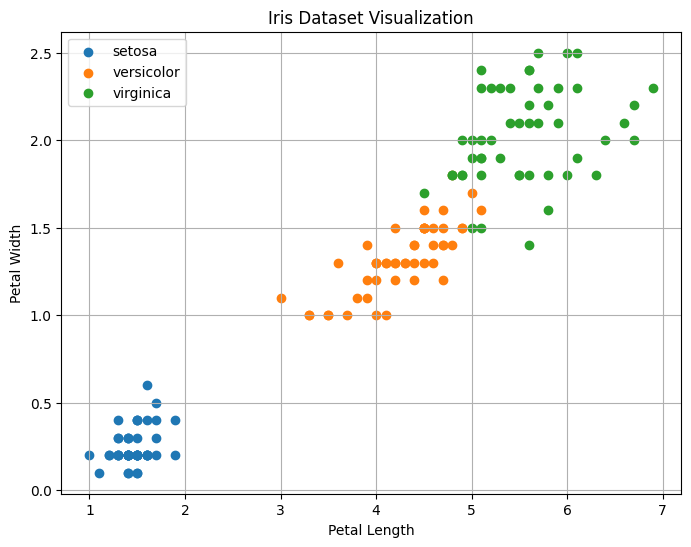

In [4]:
plt.figure(figsize=(8,6))

for flower_class in range(3):

    class_data = df[df["target"] == flower_class]

    plt.scatter(
        class_data["petal length (cm)"],
        class_data["petal width (cm)"],
        label=target_names[flower_class]
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset Visualization")

plt.legend()

plt.grid(True)

plt.show()

# Train-Test Split Explanation

The dataset is divided into training data and testing data.

* Training data is used to teach the model patterns and relationships.
* Testing data is used to evaluate the model on unseen samples.

This step is very important because evaluating the model on the same data used for training may lead to overfitting and unrealistic performance results.

In this project:

* 80% of the data is used for training
* 20% of the data is used for testing


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


# Feature Scaling Explanation

Feature scaling is applied using StandardScaler.

Machine learning algorithms such as K-Nearest Neighbors depend heavily on distance calculations. If one feature has much larger values than another feature, it can dominate the distance calculation and negatively affect the model's performance.

Scaling transforms the features into balanced ranges with:

* Mean = 0
* Standard deviation = 1

This helps all features contribute equally during model training and prediction.


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# K-Nearest Neighbors (KNN) Explanation

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification tasks.

The algorithm works by:

1. Calculating the distance between the new sample and all training samples.
2. Selecting the nearest K neighbors.
3. Choosing the majority class among the nearest neighbors.

In this project, K = 5 is initially used, meaning the algorithm checks the nearest five data points before making a prediction.


In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# Prediction Explanation

After training the KNN model, predictions are made using the testing dataset.

The model analyzes the scaled feature values of unseen flowers and predicts which class each flower belongs to based on learned patterns from the training data.

The predicted labels are then compared with the actual labels to measure the model's performance.


In [10]:
predictions = knn_model.predict(X_test_scaled)

print("Predictions:\n")
print(predictions)

print("\nActual Labels:\n")
print(y_test)

Predictions:

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]

Actual Labels:

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Model Evaluation Explanation

The model is evaluated using several performance metrics:

* Accuracy Score
* Confusion Matrix
* Precision
* Recall
* F1-Score

Accuracy measures the percentage of correctly classified samples.

The confusion matrix provides detailed insight into correct and incorrect predictions for each flower class.

Precision, recall, and F1-score provide deeper evaluation of the classification performance and help determine the reliability of the model.


In [11]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        predictions,
        target_names=target_names
    )
)

Accuracy: 0.9333333333333333

Confusion Matrix:

[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# Testing Different K Values

Different K values are tested to analyze how the number of neighbors affects model performance.

* Small K values may lead to overfitting.
* Large K values may lead to underfitting.

The goal is to find the K value that produces the highest accuracy while maintaining good generalization performance.


In [12]:
k_values = range(1, 11)

accuracies = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    accuracies.append(acc)

    print(f"K = {k}, Accuracy = {acc:.4f}")

K = 1, Accuracy = 0.9667
K = 2, Accuracy = 0.9333
K = 3, Accuracy = 0.9333
K = 4, Accuracy = 0.9333
K = 5, Accuracy = 0.9333
K = 6, Accuracy = 0.9333
K = 7, Accuracy = 0.9667
K = 8, Accuracy = 0.9333
K = 9, Accuracy = 0.9667
K = 10, Accuracy = 0.9667


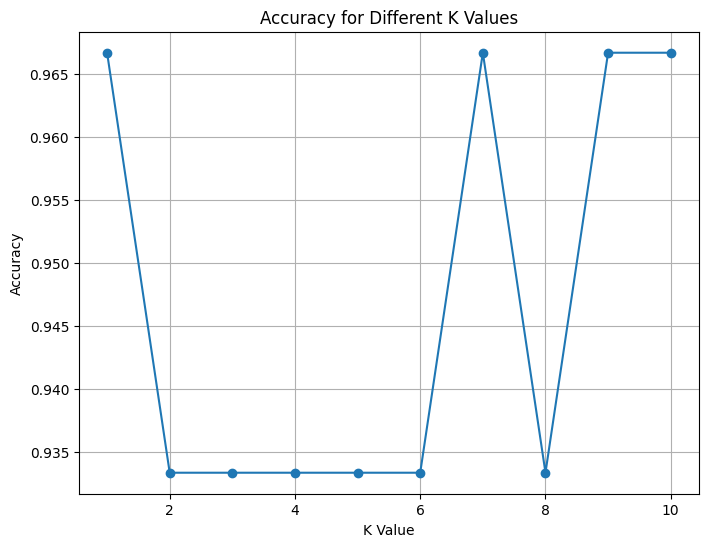

In [13]:
plt.figure(figsize=(8,6))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("Accuracy for Different K Values")

plt.grid(True)

plt.show()

# Comparing Different Machine Learning Algorithms

In addition to KNN, other machine learning algorithms are tested:

* Logistic Regression
* Decision Tree

Comparing multiple algorithms helps determine which model performs best on the Iris dataset.

This comparison also demonstrates the importance of experimentation in machine learning projects.


In [14]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(f"{name}: {acc:.4f}")

KNN: 0.9333
Logistic Regression: 0.9333
Decision Tree: 0.9333


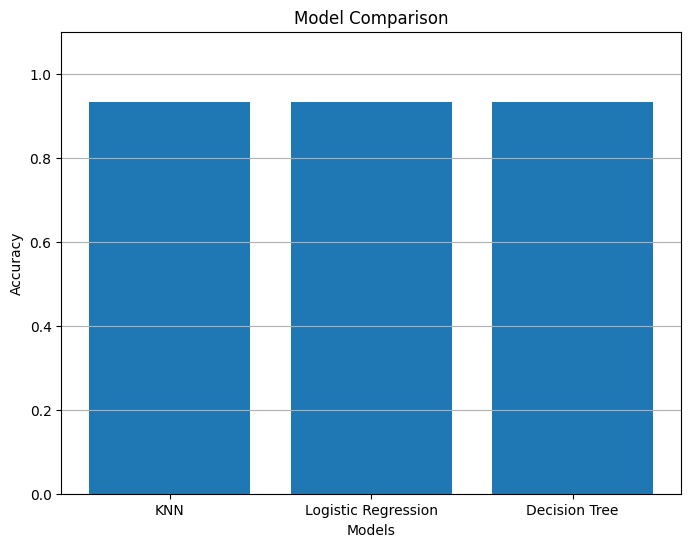

In [15]:
plt.figure(figsize=(8,6))

plt.bar(results.keys(), results.values())

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.ylim(0, 1.1)

plt.grid(axis='y')

plt.show()

In [16]:
new_flower = [[6.7, 3.0, 5.2, 2.3]]

new_flower_scaled = scaler.transform(new_flower)

prediction = knn_model.predict(new_flower_scaled)

print("Prediction Class Number:", prediction[0])

print("Flower Name:", target_names[prediction[0]])

Prediction Class Number: 2
Flower Name: virginica


# Final Conclusion

This project demonstrates a complete supervised learning workflow using the Iris dataset.

The process included:

* Loading and understanding the dataset
* Data visualization
* Train-test splitting
* Feature scaling
* Model training using KNN
* Prediction and evaluation
* Testing different K values
* Comparing multiple machine learning algorithms

The project highlights the importance of preprocessing, evaluation metrics, and algorithm selection when building AI classification systems.
